In [1]:

%load_ext autoreload
%autoreload 2

import sys

file_path = '/Users/michaelfinch/CA1-interneuron-GLM' #Mac
#file_path=r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM"

sys.path.append(file_path)

from utils_TCA_clustering_scratchpad import *
from GLM_regression_plotting import *


from modelling_to_date_utils import *

from selectivity_over_learning_utils import *

/Users/michaelfinch/CA1-interneuron-GLM/utils.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
# activity_dict, predicted_activity_dict_NDNF_new, filtered_factors_dict, new_NDNF_activity_dict, new_NDNF_velocity_dict, residual_activity_dict_NDNF_new = load_data_regular(file_path=file_path, name="NDNFanalC", new_NDNF=True)
# GLM_params, activity_dict, double_predicted_activity_dict_NDNF_new, factors_dict, filtered_factors_dict, residual_activity_dict_NDNF_new = load_data_regular(file_path=file_path, name="NDNFanalC", new_NDNF=True)
# GLM_params_old_NDNF, activity_dict_old_NDNF, double_predicted_activity_dict_NDNF_old, factors_dict_old_NDNF, filtered_factors_dict_old_NDNF, residual_activity_dict_NDNF_old = load_data_regular(file_path=file_path, name="NDNFindivsomata_GLM", new_NDNF=False)
GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST = load_data_regular(file_path=file_path, name="SSTindivsomata_GLM", new_NDNF=False)
GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC = load_data_regular(file_path=file_path, name="EC_GLM", new_NDNF=False)
GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest = load_data_regular(file_path=file_path, name="NDNF_E1A1B", new_NDNF=True)

fixed_factors_dict_NDNF_newest = subset_factors(factors_dict_NDNF_newest)
fixed_residual_activity_dict_NDNF_newest = subset_factors(residual_activity_dict_NDNF_newest)
fixed_activity_dict_NDNF_newest = subset_factors(activity_dict_NDNF_newest)



In [3]:

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_SST_model_ranks20_contig_x00_cells"
cell_SST_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_EC_model_ranks20_contig_x00_cells"
cell_EC_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/real_final_NDNF_model_ranks20_contig_x00_cell"
cell_NDNF_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

def get_cp_dict(cell_SST_model_ranks20_contig_x00):
    changepoints_dict = {}
    for animal in cell_SST_model_ranks20_contig_x00[20]:
        changepoints_cell_dict = {}
        for cell in cell_SST_model_ranks20_contig_x00[20][animal]:
            labels = cell_SST_model_ranks20_contig_x00[20][animal][cell][1][f'cell_{cell}']["labels_dict"]["clusters_chosen_3"]
            changepoints = np.where(np.diff(labels) != 0)[0]
            changepoints_cell_dict[cell] = changepoints
        changepoints_dict[animal] = changepoints_cell_dict

    return changepoints_dict



fixed_model_dict_NDNF_newest = get_fixed_model_dict_NDNF_newest(cell_NDNF_model_ranks20_contig_x00)

cp_dict_EC = get_cp_dict(cell_EC_model_ranks20_contig_x00)
cp_dict_NDNF = get_cp_dict(fixed_model_dict_NDNF_newest)
cp_dict_SST = get_cp_dict(cell_SST_model_ranks20_contig_x00)

Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 12 cells
    Animal 1: 16 cells
    Animal 2: 4 cells
    Animal 3: 10 cells
    Animal 4: 8 cells
    Animal 5: 7 cells
    Animal 6: 11 cells
    Animal 7: 10 cells
    Animal 8: 17 cells
    Animal 9: 17 cells
    Animal 10: 9 cells
    Animal 11: 6 cells
    Animal 12: 10 cells
    Animal 13: 9 cells
    Animal 14: 6 cells
    Animal 15: 12 cells
    Animal 16: 7 cells
    Animal 17: 7 cells
    Animal 18: 7 cells
    Animal 19: 10 cells
    Animal 20: 9 cells
    Animal 21: 

In [4]:
def get_cp_dict(cell_SST_model_ranks20_contig_x00):
    changepoints_dict = {}
    for animal in cell_SST_model_ranks20_contig_x00[20]:
        changepoints_cell_dict = {}
        for cell in cell_SST_model_ranks20_contig_x00[20][animal]:
            labels = cell_SST_model_ranks20_contig_x00[20][animal][cell][1][f'cell_{cell}']["labels_dict"]["clusters_chosen_3"]
            changepoints = np.where(np.diff(labels) != 0)[0]
            changepoints_cell_dict[cell] = changepoints
        changepoints_dict[animal] = changepoints_cell_dict

    return changepoints_dict



fixed_model_dict_NDNF_newest = get_fixed_model_dict_NDNF_newest(cell_NDNF_model_ranks20_contig_x00)

cp_dict_EC = get_cp_dict(cell_EC_model_ranks20_contig_x00)
cp_dict_NDNF = get_cp_dict(fixed_model_dict_NDNF_newest)
cp_dict_SST = get_cp_dict(cell_SST_model_ranks20_contig_x00)

In [5]:
def get_activity_early(activity_dict_SST, cp_dict_SST):
    SST_data_list = []
    for idx, animal in enumerate(activity_dict_SST):
        for idt, cell in enumerate(activity_dict_SST[animal]):
            cp_early = cp_dict_SST[idx][idt][0]
            SST_data_list.append(np.mean(activity_dict_SST[animal][cell][:,:cp_early], axis=1))
            # SST_data_list.append(np.mean(activity_dict_SST[animal][cell], axis=1))

    SST_data_array_early = np.array(SST_data_list)
    return SST_data_array_early

def get_activity_late(activity_dict_SST, cp_dict_SST):
    SST_data_list = []
    for idx, animal in enumerate(activity_dict_SST):
        for idt, cell in enumerate(activity_dict_SST[animal]):
            cp_late = cp_dict_SST[idx][idt][1]
            SST_data_list.append(np.mean(activity_dict_SST[animal][cell][:,-cp_late:], axis=1))
            # SST_data_list.append(np.mean(activity_dict_SST[animal][cell], axis=1))

    SST_data_array_late = np.array(SST_data_list)
    return SST_data_array_late

In [6]:
def get_cp_per_cell(activity_dict_SST, cp_dict_SST):
    early_changepoints = []
    late_changepoints = []

    for idx, animal in enumerate(activity_dict_SST):
        for idt, cell in enumerate(activity_dict_SST[animal]):
            early_cp = cp_dict_SST[idx][idt][0]
            late_cp = cp_dict_SST[idx][idt][1]
            num_trials = activity_dict_SST[animal][cell].shape[1]

            early_changepoints.append(early_cp / num_trials)
            late_changepoints.append(late_cp / num_trials)

    return early_changepoints, late_changepoints

from matplotlib.patches import Rectangle

def plot_changepoints(early, late, title="Changepoint Distribution SST Fixed Reward", ax=axs[0,0]):
    rng = np.random.default_rng(0)
    early = np.asarray(early, dtype=float)
    late  = np.asarray(late, dtype=float)
    early = early[~np.isnan(early)]
    late  = late[~np.isnan(late)]

    # fig, ax = plt.subplots(figsize=(5,5), dpi=140)

    def draw_group(data, x, color, label):
        q1, q3 = np.percentile(data, [25, 75])
        y_min, y_max = float(np.min(data)), float(np.max(data))
        mean = float(np.mean(data))

        # IQR box (light gray)
        ax.add_patch(Rectangle((x-0.18, q1), 0.36, q3-q1,
                               facecolor='0.92', edgecolor='none', zorder=0))
        # whisker min–max
        ax.vlines(x, y_min, y_max, colors='k', linewidth=2, zorder=1)
        # mean line
        ax.hlines(mean, x-0.18, x+0.18, colors='k', linewidth=2, zorder=2)

        # jittered scatter
        xs = x + rng.normal(scale=0.06, size=len(data))
        pts = ax.scatter(xs, data, s=28, color=color, alpha=0.9,
                         edgecolor='white', linewidth=0.5, zorder=3)
        return pts

    h1 = draw_group(early, x=0, color='#1f77b4', label='First')
    h2 = draw_group(late,  x=1, color='#d62728', label='Second')

    ax.set_xlim(-0.6, 1.6)
    ax.set_ylim(0, 1.0)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['First Changepoint', 'Second Changepoint'])
    ax.set_ylabel('Fraction of Total Trials')
    ax.set_title(title)
    # ax.legend(handles=[h1, h2], labels=['First', 'Second'], frameon=False, loc='upper left')

    # plt.tight_layout()
    # return fig, ax

def plot_changepoint(SST_data_array_early_r, SST_data_array_late_r, early_changepoints, late_changepoints, cell_type="SST", color_e='cyan', color_l='blue'):
    fig, axs = plt.subplots(2,2, figsize=(15,15))

    plt.suptitle(cell_type)

    plot_mean_fill(SST_data_array_early_r, SST_data_array_late_r, color_e=color_e, color_l=color_l, title="Early vs Late Learn Cut By Contiguous K-Means", ax=axs[0,0])
    plot_changepoints(early_changepoints, late_changepoints, title="Changepoint Distribution", ax=axs[0,1])

    im=axs[1,0].imshow(SST_data_array_early_r, aspect='auto')
    axs[1,0].set_title("Trial Averaged Population Activity Early Learn")
    axs[1,0].set_ylabel("Cell ID")
    axs[1,0].set_xlabel("Position Bin")
    fig.colorbar(im, ax=axs[1,0])

    im=axs[1,1].imshow(SST_data_array_late_r, aspect='auto')
    axs[1,1].set_title("Trial Averaged Population Activity Late Learn")
    axs[1,1].set_ylabel("Cell ID")
    axs[1,1].set_xlabel("Position Bin")
    fig.colorbar(im, ax=axs[1,1])

    plt.tight_layout()
    plt.show()

e_cp_SST, l_cp_SST = get_cp_per_cell(activity_dict_SST, cp_dict_SST)
plot_changepoint(SST_data_array_early_r, SST_data_array_late_r, e_cp_SST, l_cp_SST, cell_type="SST Velocity Subtracted Residuals", color_e='cyan', color_l='blue')

e_cp_NDNF, l_cp_NDNF = get_cp_per_cell(fixed_activity_dict_NDNF_newest, cp_dict_NDNF)
plot_changepoint(NDNF_data_array_early_r, NDNF_data_array_late_r, e_cp_NDNF, l_cp_NDNF, cell_type="NDNF Velocity Subtracted Residuals", color_e='orange', color_l='red')

e_cp_EC, l_cp_EC = get_cp_per_cell(activity_dict_EC, cp_dict_EC)
plot_changepoint(EC_data_array_early_r, EC_data_array_late_r, e_cp_EC, l_cp_EC, cell_type="EC Velocity Subtracted Residuals", color_e='k', color_l='green')




NameError: name 'axs' is not defined

In [ ]:
fixed_residual_activity_dict_NDNF_newest.keys()

dict_keys(['animal_19', 'animal_20', 'animal_21', 'animal_22', 'animal_23', 'animal_24', 'animal_25', 'animal_26', 'animal_27', 'animal_28', 'animal_29', 'animal_30', 'animal_31'])

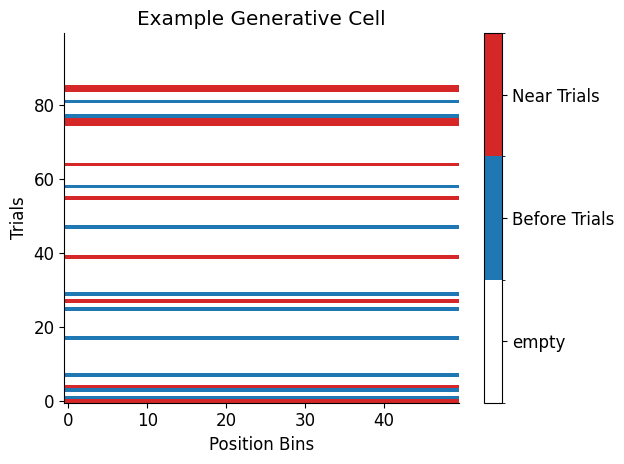

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

n_rows, n_cols = 50, 100
cell = np.zeros((n_rows, n_cols), dtype=int)

# Choose distinct columns
rng = np.random.default_rng(0)
trials_one = rng.choice(n_cols, size=10, replace=False)
remaining = np.setdiff1d(np.arange(n_cols), trials_one)
trials_two = rng.choice(remaining, size=10, replace=False)

# Fill columns with 1s and 2s
cell[:, trials_one] = 1
cell[:, trials_two] = 2  # will not overwrite 1s because sets are disjoint

# Discrete colormap: 0=white, 1=blue, 2=red
cmap = ListedColormap(['white', '#1f77b4', '#d62728'])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

plt.figure()
im = plt.imshow(cell.T, aspect='auto', cmap=cmap, norm=norm, origin='lower')
cbar = plt.colorbar(im, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(['empty', 'Before Trials', 'Near Trials'])
plt.ylabel('Trials')
plt.xlabel('Position Bins')
plt.title("Example Generative Cell")
plt.tight_layout()
plt.show()


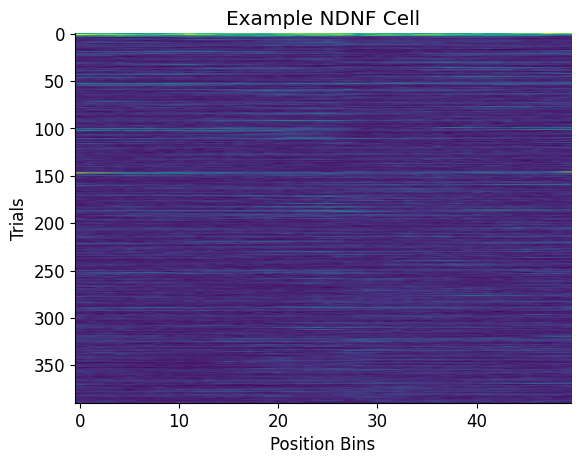

In [ ]:
plt.imshow(fixed_residual_activity_dict_NDNF_newest['animal_20']['cell_2'].T, aspect='auto')
plt.title("Example NDNF Cell")
plt.xlabel("Position Bins")
plt.ylabel("Trials")
plt.show()

In [ ]:
SST_data_array_early_r = get_activity_early(residual_activity_dict_SST, cp_dict_SST)
SST_data_array_late_r = get_activity_late(residual_activity_dict_SST, cp_dict_SST)

EC_data_array_early_r = get_activity_early(residual_activity_dict_EC, cp_dict_EC)
EC_data_array_late_r = get_activity_late(residual_activity_dict_EC, cp_dict_EC)

NDNF_data_array_early_r = get_activity_early(fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF)
NDNF_data_array_late_r = get_activity_late(fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF)

In [ ]:
SST_data_array_early = get_activity_early(activity_dict_SST, cp_dict_SST)
SST_data_array_late = get_activity_late(activity_dict_SST, cp_dict_SST)

EC_data_array_early = get_activity_early(activity_dict_EC, cp_dict_EC)
EC_data_array_late = get_activity_late(activity_dict_EC, cp_dict_EC)

NDNF_data_array_early = get_activity_early(fixed_activity_dict_NDNF_newest, cp_dict_NDNF)
NDNF_data_array_late = get_activity_late(fixed_activity_dict_NDNF_newest, cp_dict_NDNF)

In [ ]:

def plot_mean_fill(SST_data_array_early, SST_data_array_late, color_e='cyan', color_l='blue', title="SST Early vs Late Learn Cut By Contiguous K-Means", ax=axs[0,0]):

    mean_SST_data_array_early = np.mean(SST_data_array_early, axis=0)
    sem_SST_data_array_early = sem(SST_data_array_early, axis=0)
    mean_SST_data_array_late = np.mean(SST_data_array_late, axis=0)
    sem_SST_data_array_late = sem(SST_data_array_late, axis=0)

    ax.plot(mean_SST_data_array_early, color=color_e, label='Early')
    ax.fill_between(range(len(mean_SST_data_array_early)), mean_SST_data_array_early-sem_SST_data_array_early, mean_SST_data_array_early+sem_SST_data_array_early, alpha=0.2, color=color_e)
    ax.plot(mean_SST_data_array_late, color=color_l, label='Late')
    ax.fill_between(range(len(mean_SST_data_array_late)), mean_SST_data_array_late-sem_SST_data_array_late, mean_SST_data_array_late+sem_SST_data_array_late, alpha=0.2, color=color_l)
    ax.set_xlabel("Position Bins")
    ax.set_ylabel("Z-Scored DF/F")
    ax.set_title(title)
    ax.legend()
    ax.set_ylim(-0.6, 0.6)
    # plt.show()


# plot_mean_fill(EC_data_array_early, EC_data_array_late, color_e='k', color_l='green', title="EC Raw Early vs Late Learn Contiguous K-Means")
# plot_mean_fill(SST_data_array_early, SST_data_array_late, color_e='cyan', color_l='blue', title="SST Raw Early vs Late Learn Contiguous K-Means")
# plot_mean_fill(NDNF_data_array_early, NDNF_data_array_late, color_e='orange', color_l='red', title="NDNF Raw Early vs Late Learn Contiguous K-Means")


plot_mean_fill(EC_data_array_early_r, EC_data_array_late_r, color_e='k', color_l='green', title="EC Residuals Early vs Late Learn Contiguous K-Means")
plot_mean_fill(SST_data_array_early_r, SST_data_array_late_r, color_e='cyan', color_l='blue', title="SST Residuals Early vs Late Learn Contiguous K-Means")
plot_mean_fill(NDNF_data_array_early_r, NDNF_data_array_late_r, color_e='orange', color_l='red', title="NDNF Residuals Early vs Late Learn Contiguous K-Means")


Help on function get_binned_data_for_CDF in module selectivity_over_learning_utils:

get_binned_data_for_CDF(animal_average_selectivity_dict_SST_r, n_bins=20)
    params animal_average_selectivity_dict_SST_r: selectivity value for every cell in a dict
    returns binned_data: the cells with selectiivty values that fit within each bin (percent of data)

Help on function get_selectivity_each_trial in module selectivity_over_learning_utils:

get_selectivity_each_trial(activity_dict_EC, neg_sel=True, trial_av=False)
    - get a selectivity for every trial of every cell and then average it to be the selectivity for that cell or trial_av will trial average first and then run the selectivity on that trial averaged trace  if the trial_av flag is False
    returns: animal_average_selectivity_dict - every cell gets a single value from either the selectivity of the trial averaged trace or the average of all selectivity metrics quantified for every trial individually



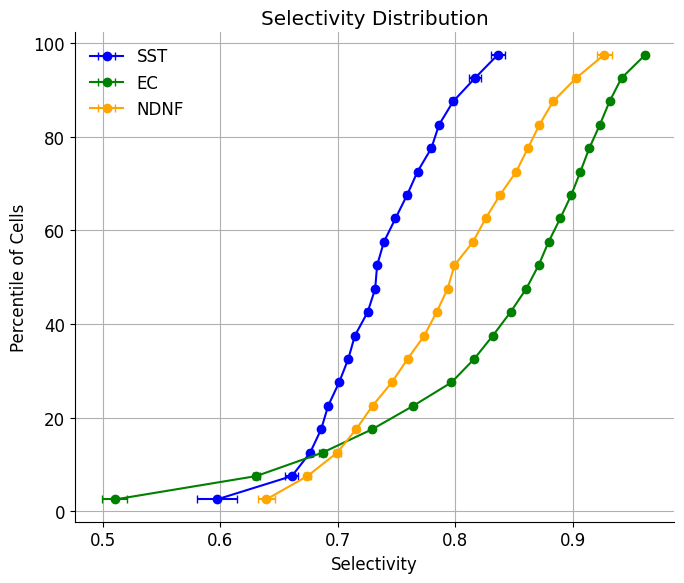

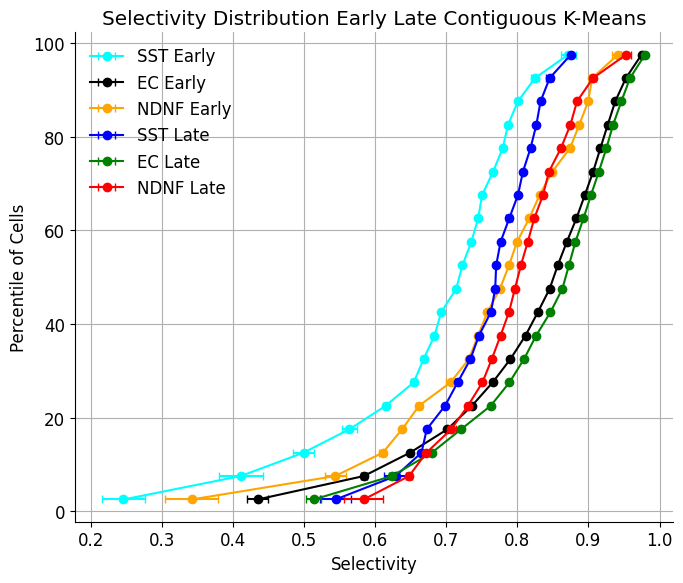

In [ ]:


help(get_binned_data_for_CDF)
help(get_selectivity_each_trial)


animal_average_selectivity_dict_EC_r = get_selectivity_each_trial(residual_activity_dict_EC, neg_sel=False, trial_av=False)
animal_average_selectivity_dict_SST_r = get_selectivity_each_trial(residual_activity_dict_SST, neg_sel=False, trial_av=False)
animal_average_selectivity_dict_NDNF_r = get_selectivity_each_trial(fixed_activity_dict_NDNF_newest, neg_sel=False, trial_av=False)



binned_data_SST = get_binned_data_for_CDF(animal_average_selectivity_dict_SST_r, n_bins=20)
binned_data_EC = get_binned_data_for_CDF(animal_average_selectivity_dict_EC_r, n_bins=20)
binned_data_NDNF = get_binned_data_for_CDF(animal_average_selectivity_dict_NDNF_r, n_bins=20)

plot_the_CDF(binned_data_SST, binned_data_EC, binned_data_NDNF, title="Selectivity Distribution")


animal_average_selectivity_dict_EC_r_early = get_selectivity_each_trial_early_late(residual_activity_dict_EC, cp_dict_EC, neg_sel=True, trial_av=False, use_early=True)
animal_average_selectivity_dict_SST_r_early = get_selectivity_each_trial_early_late(residual_activity_dict_SST, cp_dict_SST, neg_sel=False, trial_av=False, use_early=True)
animal_average_selectivity_dict_NDNF_r_early = get_selectivity_each_trial_early_late(fixed_activity_dict_NDNF_newest, cp_dict_NDNF, neg_sel=False, trial_av=False, use_early=True)

animal_average_selectivity_dict_EC_r_late = get_selectivity_each_trial_early_late(residual_activity_dict_EC, cp_dict_EC, neg_sel=True, trial_av=False, use_early=False)
animal_average_selectivity_dict_SST_r_late = get_selectivity_each_trial_early_late(residual_activity_dict_SST, cp_dict_SST, neg_sel=False, trial_av=False, use_early=False)
animal_average_selectivity_dict_NDNF_r_late = get_selectivity_each_trial_early_late(fixed_activity_dict_NDNF_newest, cp_dict_NDNF, neg_sel=False, trial_av=False, use_early=False)

binned_data_SST_e = get_binned_data_for_CDF(animal_average_selectivity_dict_SST_r_early, n_bins=20)
binned_data_EC_e = get_binned_data_for_CDF(animal_average_selectivity_dict_EC_r_early, n_bins=20)
binned_data_NDNF_e = get_binned_data_for_CDF(animal_average_selectivity_dict_NDNF_r_early, n_bins=20)

binned_data_SST_l = get_binned_data_for_CDF(animal_average_selectivity_dict_SST_r_late, n_bins=20)
binned_data_EC_l = get_binned_data_for_CDF(animal_average_selectivity_dict_EC_r_late, n_bins=20)
binned_data_NDNF_l = get_binned_data_for_CDF(animal_average_selectivity_dict_NDNF_r_late, n_bins=20)

plot_the_CDF_early_late(binned_data_SST_e, binned_data_EC_e, binned_data_NDNF_e, binned_data_SST_l, binned_data_EC_l, binned_data_NDNF_l, title="Selectivity Distribution Early Late Contiguous K-Means")

Help on function get_binned_data_for_CDF in module selectivity_over_learning_utils:

get_binned_data_for_CDF(animal_average_selectivity_dict_SST_r, n_bins=20)
    params animal_average_selectivity_dict_SST_r: selectivity value for every cell in a dict
    returns binned_data: the cells with selectiivty values that fit within each bin (percent of data)

Help on function get_selectivity_each_trial in module selectivity_over_learning_utils:

get_selectivity_each_trial(activity_dict_EC, neg_sel=True, trial_av=False)
    - get a selectivity for every trial of every cell and then average it to be the selectivity for that cell or trial_av will trial average first and then run the selectivity on that trial averaged trace  if the trial_av flag is False
    returns: animal_average_selectivity_dict - every cell gets a single value from either the selectivity of the trial averaged trace or the average of all selectivity metrics quantified for every trial individually



/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/selectivity_over_learning_utils.py:153: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  sem_data_list.append(sem(bin_data))


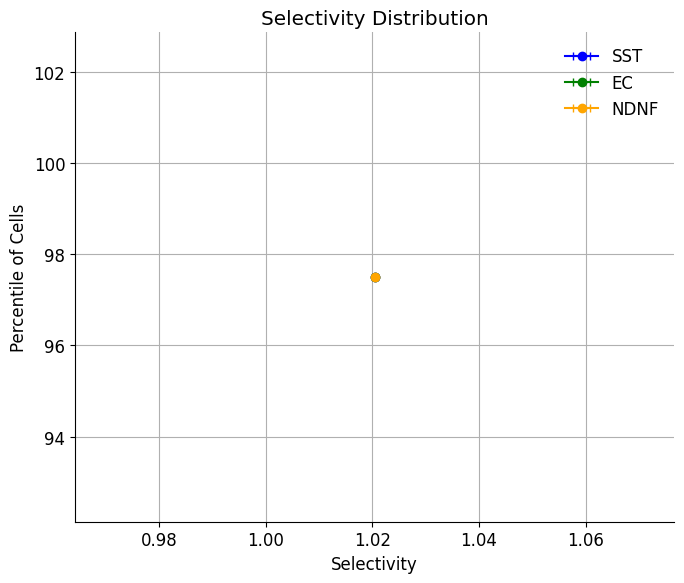

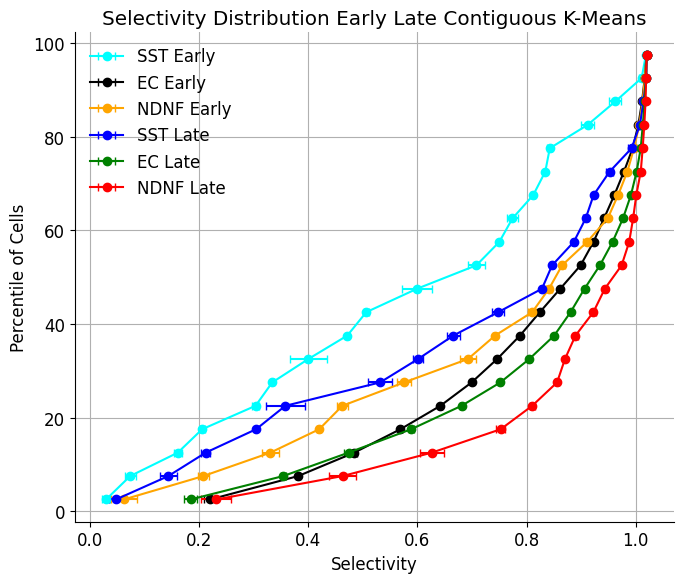

In [ ]:


help(get_binned_data_for_CDF)
help(get_selectivity_each_trial)


ta=True

animal_average_selectivity_dict_EC_r = get_selectivity_each_trial(residual_activity_dict_EC, neg_sel=False, trial_av=ta)
animal_average_selectivity_dict_SST_r = get_selectivity_each_trial(residual_activity_dict_SST, neg_sel=False, trial_av=ta)
animal_average_selectivity_dict_NDNF_r = get_selectivity_each_trial(fixed_activity_dict_NDNF_newest, neg_sel=False, trial_av=ta)



binned_data_SST = get_binned_data_for_CDF(animal_average_selectivity_dict_SST_r, n_bins=20)
binned_data_EC = get_binned_data_for_CDF(animal_average_selectivity_dict_EC_r, n_bins=20)
binned_data_NDNF = get_binned_data_for_CDF(animal_average_selectivity_dict_NDNF_r, n_bins=20)

plot_the_CDF(binned_data_SST, binned_data_EC, binned_data_NDNF, title="Selectivity Distribution")


animal_average_selectivity_dict_EC_r_early = get_selectivity_each_trial_early_late(residual_activity_dict_EC, cp_dict_EC, neg_sel=True, trial_av=ta, use_early=True)
animal_average_selectivity_dict_SST_r_early = get_selectivity_each_trial_early_late(residual_activity_dict_SST, cp_dict_SST, neg_sel=False, trial_av=ta, use_early=True)
animal_average_selectivity_dict_NDNF_r_early = get_selectivity_each_trial_early_late(fixed_activity_dict_NDNF_newest, cp_dict_NDNF, neg_sel=False, trial_av=ta, use_early=True)

animal_average_selectivity_dict_EC_r_late = get_selectivity_each_trial_early_late(residual_activity_dict_EC, cp_dict_EC, neg_sel=True, trial_av=ta, use_early=False)
animal_average_selectivity_dict_SST_r_late = get_selectivity_each_trial_early_late(residual_activity_dict_SST, cp_dict_SST, neg_sel=False, trial_av=ta, use_early=False)
animal_average_selectivity_dict_NDNF_r_late = get_selectivity_each_trial_early_late(fixed_activity_dict_NDNF_newest, cp_dict_NDNF, neg_sel=False, trial_av=ta, use_early=False)

binned_data_SST_e = get_binned_data_for_CDF(animal_average_selectivity_dict_SST_r_early, n_bins=20)
binned_data_EC_e = get_binned_data_for_CDF(animal_average_selectivity_dict_EC_r_early, n_bins=20)
binned_data_NDNF_e = get_binned_data_for_CDF(animal_average_selectivity_dict_NDNF_r_early, n_bins=20)

binned_data_SST_l = get_binned_data_for_CDF(animal_average_selectivity_dict_SST_r_late, n_bins=20)
binned_data_EC_l = get_binned_data_for_CDF(animal_average_selectivity_dict_EC_r_late, n_bins=20)
binned_data_NDNF_l = get_binned_data_for_CDF(animal_average_selectivity_dict_NDNF_r_late, n_bins=20)

plot_the_CDF_early_late(binned_data_SST_e, binned_data_EC_e, binned_data_NDNF_e, binned_data_SST_l, binned_data_EC_l, binned_data_NDNF_l, title="Selectivity Distribution Early Late Contiguous K-Means")

In [ ]:
setup_CDF_plotting_for_selectivity(activity_dict_SST, predicted_activity_dict_SST, activity_dict_NDNF, predicted_activity_dict_NDNF, activity_dict_EC, predicted_activity_dict_EC, residual=False)

NameError: name 'predicted_activity_dict_SST' is not defined

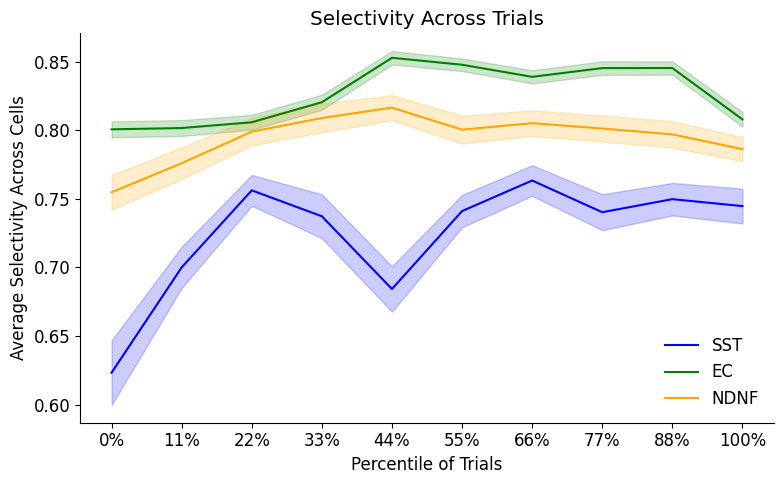

In [ ]:

################# plotting selectivity by percentile of trials --- didnt work 



# def Vinje2000(tuning_curve, norm='None', negative_selectivity=False):
    # if norm == 'min_max':
    #     tuning_curve = (tuning_curve - np.min(tuning_curve)) / (np.max(tuning_curve) - np.min(tuning_curve))
    #     if negative_selectivity:
    #         tuning_curve = np.absolute(1 - tuning_curve)
    # elif norm == 'z_score':
    #     tuning_curve = (tuning_curve - np.mean(tuning_curve)) / np.std(tuning_curve)
    #     if negative_selectivity:
    #         tuning_curve = np.absolute(1 - tuning_curve)
    # A = np.mean(tuning_curve) ** 2 / np.mean(tuning_curve ** 2)
    # return (1 - A) / (1 - 1 / len(tuning_curve))


# def get_selectivity_for_plotting(activity_dict_SST, predicted_activity_dict_SST, residual=False):

taa=False

percentile_slices_SST = get_percentlie_slices(activity_dict_SST)
percentile_slices_NDNF = get_percentlie_slices(fixed_activity_dict_NDNF_newest)
percentile_slices_EC = get_percentlie_slices(activity_dict_EC)

percentile_slices_SST_r = get_percentlie_slices(residual_activity_dict_SST)
percentile_slices_NDNF_r = get_percentlie_slices(fixed_residual_activity_dict_NDNF_newest)
percentile_slices_EC_r = get_percentlie_slices(residual_activity_dict_EC)


animal_average_selectivity_dict_SST = get_animal_average_selectivity_dict(percentile_slices_SST, neg_sel=False, trial_av=taa)
animal_average_selectivity_dict_EC = get_animal_average_selectivity_dict(percentile_slices_EC, neg_sel=False, trial_av=taa)
animal_average_selectivity_dict_NDNF = get_animal_average_selectivity_dict(percentile_slices_NDNF, neg_sel=False, trial_av=taa)


animal_average_selectivity_dict_SST_r = get_animal_average_selectivity_dict(percentile_slices_SST_r, neg_sel=False, trial_av=taa)
animal_average_selectivity_dict_EC_r = get_animal_average_selectivity_dict(percentile_slices_EC_r, neg_sel=False, trial_av=taa)
animal_average_selectivity_dict_NDNF_r = get_animal_average_selectivity_dict(percentile_slices_NDNF_r, neg_sel=False, trial_av=taa)

all_cell_selectivity_SST = get_selectivity_array(animal_average_selectivity_dict_SST)
all_cell_selectivity_EC = get_selectivity_array(animal_average_selectivity_dict_EC)
all_cell_selectivity_NDNF = get_selectivity_array(animal_average_selectivity_dict_NDNF)

# Step 3: compute mean and SEM across cells




plot_selectivity_over_trials(all_cell_selectivity_SST, all_cell_selectivity_EC, all_cell_selectivity_NDNF)


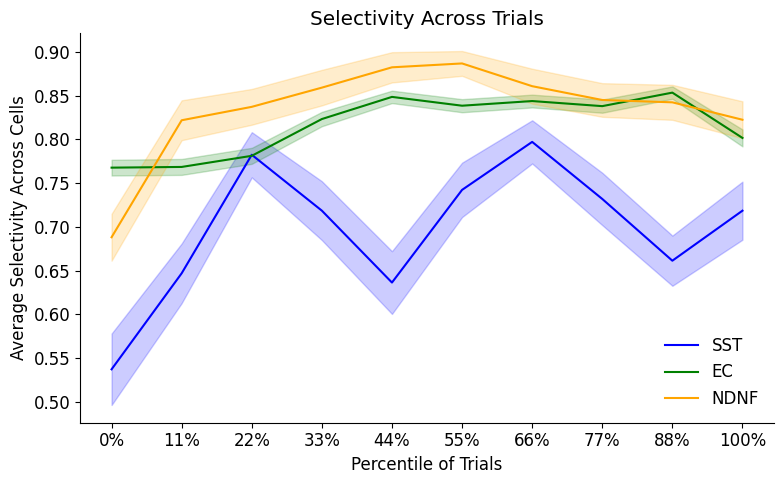

In [ ]:

################# plotting selectivity by percentile of trials --- didnt work 



# def Vinje2000(tuning_curve, norm='None', negative_selectivity=False):
    # if norm == 'min_max':
    #     tuning_curve = (tuning_curve - np.min(tuning_curve)) / (np.max(tuning_curve) - np.min(tuning_curve))
    #     if negative_selectivity:
    #         tuning_curve = np.absolute(1 - tuning_curve)
    # elif norm == 'z_score':
    #     tuning_curve = (tuning_curve - np.mean(tuning_curve)) / np.std(tuning_curve)
    #     if negative_selectivity:
    #         tuning_curve = np.absolute(1 - tuning_curve)
    # A = np.mean(tuning_curve) ** 2 / np.mean(tuning_curve ** 2)
    # return (1 - A) / (1 - 1 / len(tuning_curve))


# def get_selectivity_for_plotting(activity_dict_SST, predicted_activity_dict_SST, residual=False):

taa=True

percentile_slices_SST = get_percentlie_slices(activity_dict_SST)
percentile_slices_NDNF = get_percentlie_slices(fixed_activity_dict_NDNF_newest)
percentile_slices_EC = get_percentlie_slices(activity_dict_EC)

percentile_slices_SST_r = get_percentlie_slices(residual_activity_dict_SST)
percentile_slices_NDNF_r = get_percentlie_slices(fixed_residual_activity_dict_NDNF_newest)
percentile_slices_EC_r = get_percentlie_slices(residual_activity_dict_EC)


animal_average_selectivity_dict_SST = get_animal_average_selectivity_dict(percentile_slices_SST, neg_sel=False, trial_av=taa)
animal_average_selectivity_dict_EC = get_animal_average_selectivity_dict(percentile_slices_EC, neg_sel=False, trial_av=taa)
animal_average_selectivity_dict_NDNF = get_animal_average_selectivity_dict(percentile_slices_NDNF, neg_sel=False, trial_av=taa)


animal_average_selectivity_dict_SST_r = get_animal_average_selectivity_dict(percentile_slices_SST_r, neg_sel=False, trial_av=taa)
animal_average_selectivity_dict_EC_r = get_animal_average_selectivity_dict(percentile_slices_EC_r, neg_sel=False, trial_av=taa)
animal_average_selectivity_dict_NDNF_r = get_animal_average_selectivity_dict(percentile_slices_NDNF_r, neg_sel=False, trial_av=taa)

all_cell_selectivity_SST = get_selectivity_array(animal_average_selectivity_dict_SST)
all_cell_selectivity_EC = get_selectivity_array(animal_average_selectivity_dict_EC)
all_cell_selectivity_NDNF = get_selectivity_array(animal_average_selectivity_dict_NDNF)

# Step 3: compute mean and SEM across cells




plot_selectivity_over_trials(all_cell_selectivity_SST, all_cell_selectivity_EC, all_cell_selectivity_NDNF)


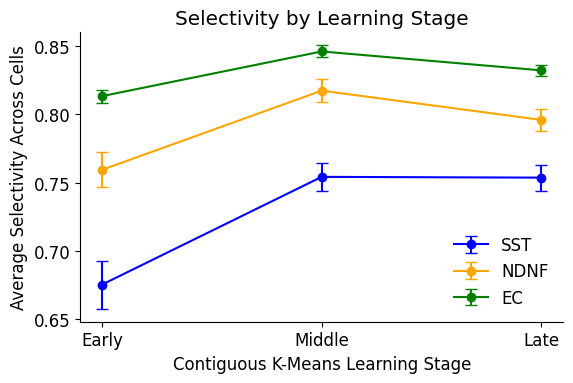

In [ ]:
########### split by learning chunk 

tas=False

animal_average_selectivity_dict_SST = get_animal_average_selectivity_dict_eml(residual_activity_dict_SST, cp_dict_SST, neg_sel=True, trial_av=tas)
animal_average_selectivity_dict_EC = get_animal_average_selectivity_dict_eml(residual_activity_dict_EC, cp_dict_EC, neg_sel=True, trial_av=tas)
animal_average_selectivity_dict_NDNF = get_animal_average_selectivity_dict_eml(fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF, neg_sel=True, trial_av=tas)

plot_selectivity_seperated_by_learn_stage(animal_average_selectivity_dict_SST, animal_average_selectivity_dict_NDNF, animal_average_selectivity_dict_EC)


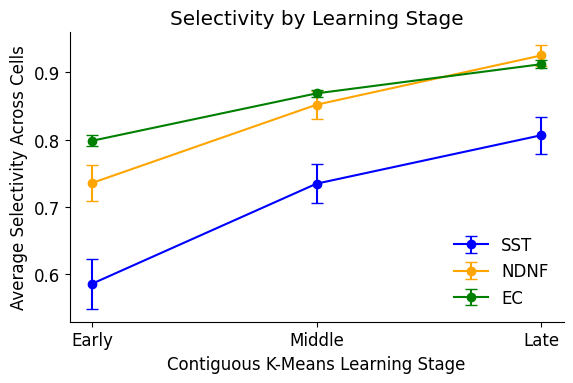

In [ ]:
########### split by learning chunk 

tas=True

animal_average_selectivity_dict_SST = get_animal_average_selectivity_dict_eml(residual_activity_dict_SST, cp_dict_SST, neg_sel=True, trial_av=tas)
animal_average_selectivity_dict_EC = get_animal_average_selectivity_dict_eml(residual_activity_dict_EC, cp_dict_EC, neg_sel=True, trial_av=tas)
animal_average_selectivity_dict_NDNF = get_animal_average_selectivity_dict_eml(fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF, neg_sel=True, trial_av=tas)

plot_selectivity_seperated_by_learn_stage(animal_average_selectivity_dict_SST, animal_average_selectivity_dict_NDNF, animal_average_selectivity_dict_EC)
